In [25]:
import os
import sys

# Set environment variables BEFORE any TensorFlow import
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import DenseNet121

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## ⚡ GPU/CUDA Configuration - RTX 3050 with CUDA 12

**✅ Setup Status:**
- NVIDIA RTX 3050 GPU: Installed
- CUDA 12 packages: Installed (`nvidia-cuda-runtime-cu12`, `nvidia-cudnn-cu12`, etc.)
- TensorFlow 2.20.0: Compiled with CUDA 12.5 support

**📌 IMPORTANT:** If GPU is not detected after running cell 1:
1. Click **Kernel → Restart Kernel** in the menu
2. Re-run cell 1 (imports)
3. Re-run this verification cell

The kernel needs to be restarted after CUDA package installation to properly load GPU drivers.

In [26]:
# GPU and CUDA Setup Verification for RTX 3050
import sys

print("\n" + "=" * 90)
print("🎮 NVIDIA RTX 3050 GPU & CUDA VERIFICATION")
print("=" * 90)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print(f"\n📦 Software Versions:")
print(f"  - TensorFlow: {tf.__version__}")
print(f"  - Keras: {tf.keras.__version__}")
print(f"  - Python: {sys.version.split()[0]}")
print(f"  - CUDA: 12.x (via pip packages)")

print(f"\n🖥️  Hardware Detection:")
print(f"  - GPUs Available: {len(gpus)}")
print(f"  - CPUs Available: {len(cpus)}")

if gpus:
    print("\n✅ GPU DETECTED AND READY!")
    for i, gpu in enumerate(gpus):
        print(f"   GPU {i}: {gpu}")
    
    # Configure GPU memory
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("\n✓ GPU Memory Growth: ENABLED (Dynamic allocation)")
        print("✓ VRAM Management: Active (prevents OOM errors)")
        
        # GPU test
        print("\n🧪 Running GPU Computation Test...")
        with tf.device('/GPU:0'):
            test_a = tf.random.normal((1000, 1000))
            test_b = tf.random.normal((1000, 1000))
            test_result = tf.matmul(test_a, test_b)
        
        print("✅ GPU Computation Test: SUCCESS!")
        print("\n🚀 GPU IS READY FOR TRAINING!")
        print("   Expected speedup: ~10-20x faster than CPU")
        print("   Training time: ~30-45 min for 100 epochs")
        
    except Exception as e:
        print(f"\n⚠️  Error during GPU configuration: {e}")
        print("   Falling back to CPU...")
else:
    print("\n⚠️  No GPU detected in this kernel session")
    print("   🔄 SOLUTION: Restart the Jupyter kernel")
    print("   📋 Steps:")
    print("      1. Click 'Kernel' menu")
    print("      2. Select 'Restart Kernel'")
    print("      3. Run this cell again")
    print("   CPU will be used for now (training will be slower)")

print("\n" + "=" * 90)
print("✨ READY TO START TRAINING! ✨")
print("=" * 90 + "\n")


🎮 NVIDIA RTX 3050 GPU & CUDA VERIFICATION

📦 Software Versions:
  - TensorFlow: 2.20.0
  - Keras: 3.12.0
  - Python: 3.13.7
  - CUDA: 12.x (via pip packages)

🖥️  Hardware Detection:
  - GPUs Available: 1
  - CPUs Available: 1

✅ GPU DETECTED AND READY!
   GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✓ GPU Memory Growth: ENABLED (Dynamic allocation)
✓ VRAM Management: Active (prevents OOM errors)

🧪 Running GPU Computation Test...
✅ GPU Computation Test: SUCCESS!

🚀 GPU IS READY FOR TRAINING!
   Expected speedup: ~10-20x faster than CPU
   Training time: ~30-45 min for 100 epochs

✨ READY TO START TRAINING! ✨



In [27]:
# ⚠️ IMPORTANT: Run this cell AFTER CUDA 12 packages finish installing
# Restart the kernel first: Kernel -> Restart Kernel

import importlib
import sys

print("\n" + "=" * 90)
print("🔧 CUDA 12 INSTALLATION VERIFICATION")
print("=" * 90)

# Check if NVIDIA packages are installed
nvidia_packages = [
    'nvidia.cuda_runtime',
    'nvidia.cudnn',
    'nvidia.cublas',
    'nvidia.cufft',
    'nvidia.cusparse',
    'nvidia.cusolver',
    'nvidia.curand',
    'nvidia.nccl',
]

print(f"\n✓ Checking NVIDIA packages...")
packages_found = 0
for pkg in nvidia_packages:
    try:
        importlib.import_module(pkg)
        print(f"  ✅ {pkg}")
        packages_found += 1
    except ImportError:
        print(f"  ❌ {pkg} - Not installed yet")

print(f"\n📊 Status: {packages_found}/{len(nvidia_packages)} packages found")

if packages_found == len(nvidia_packages):
    print("\n✅ ALL CUDA 12 PACKAGES INSTALLED!")
    print("\n🔄 You must RESTART THE KERNEL for GPU to be detected")
    print("   Go to: Kernel → Restart Kernel")
    print("   Then run the GPU verification cell again")
else:
    print(f"\n⏳ Still installing... {len(nvidia_packages) - packages_found} packages pending")
    print("   Please wait and run this cell again")

print("\n" + "=" * 90)


🔧 CUDA 12 INSTALLATION VERIFICATION

✓ Checking NVIDIA packages...
  ✅ nvidia.cuda_runtime
  ✅ nvidia.cudnn
  ✅ nvidia.cublas
  ✅ nvidia.cufft
  ✅ nvidia.cusparse
  ✅ nvidia.cusolver
  ✅ nvidia.curand
  ✅ nvidia.nccl

📊 Status: 8/8 packages found

✅ ALL CUDA 12 PACKAGES INSTALLED!

🔄 You must RESTART THE KERNEL for GPU to be detected
   Go to: Kernel → Restart Kernel
   Then run the GPU verification cell again



<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;"> 2 | Loading The DataSet</h1>
</div>

**WORKING**
- The `image_dataset_from_directory` function is used to load image data from a directory.
- Images are resized to 256x256 pixels and grouped into batches of 32 for training efficiency.
- Labels are inferred from the directory structure and represented in a categorical format.
- Pixel values of the images are normalized to a range of [0, 1] by dividing by 255.0.

In [28]:
train_data = tf.keras.utils.image_dataset_from_directory(
    './Tea_Leaf_Disease',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32)

train_data = train_data.map(lambda x, y: (x / 255.0, y))

Found 5867 files belonging to 6 classes.


**WORKING**
- The image_dataset_from_directory function is used to load validation image data from a directory.
- Images are resized to 256x256 pixels and grouped into batches of 32 for efficient processing.
- Labels are inferred from the directory structure and represented in a categorical format.
- Pixel values of the images are normalized to a range of [0, 1] by dividing by 255.0 for consistent model training.

In [29]:
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    './Tea_Leaf_Disease',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32)

val_data = val_data.map(lambda x, y: (x / 255.0, y))

Found 5867 files belonging to 6 classes.


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;"> 3 | Visualizing The Data</h1>
</div>

**WORKING**

- The code sets the `path to a directory containing images` of tomato leaves affected by the Tomato Yellow Leaf Curl Virus and so on in the next cells of code.
- It retrieves a list of all image file names in the directory.
- Using matplotlib, it displays the first 6 images along with their corresponding labels.
- For each image, it loads the image, displays it in a subplot, and sets the title to the image label, showing the visual representation of the dataset.

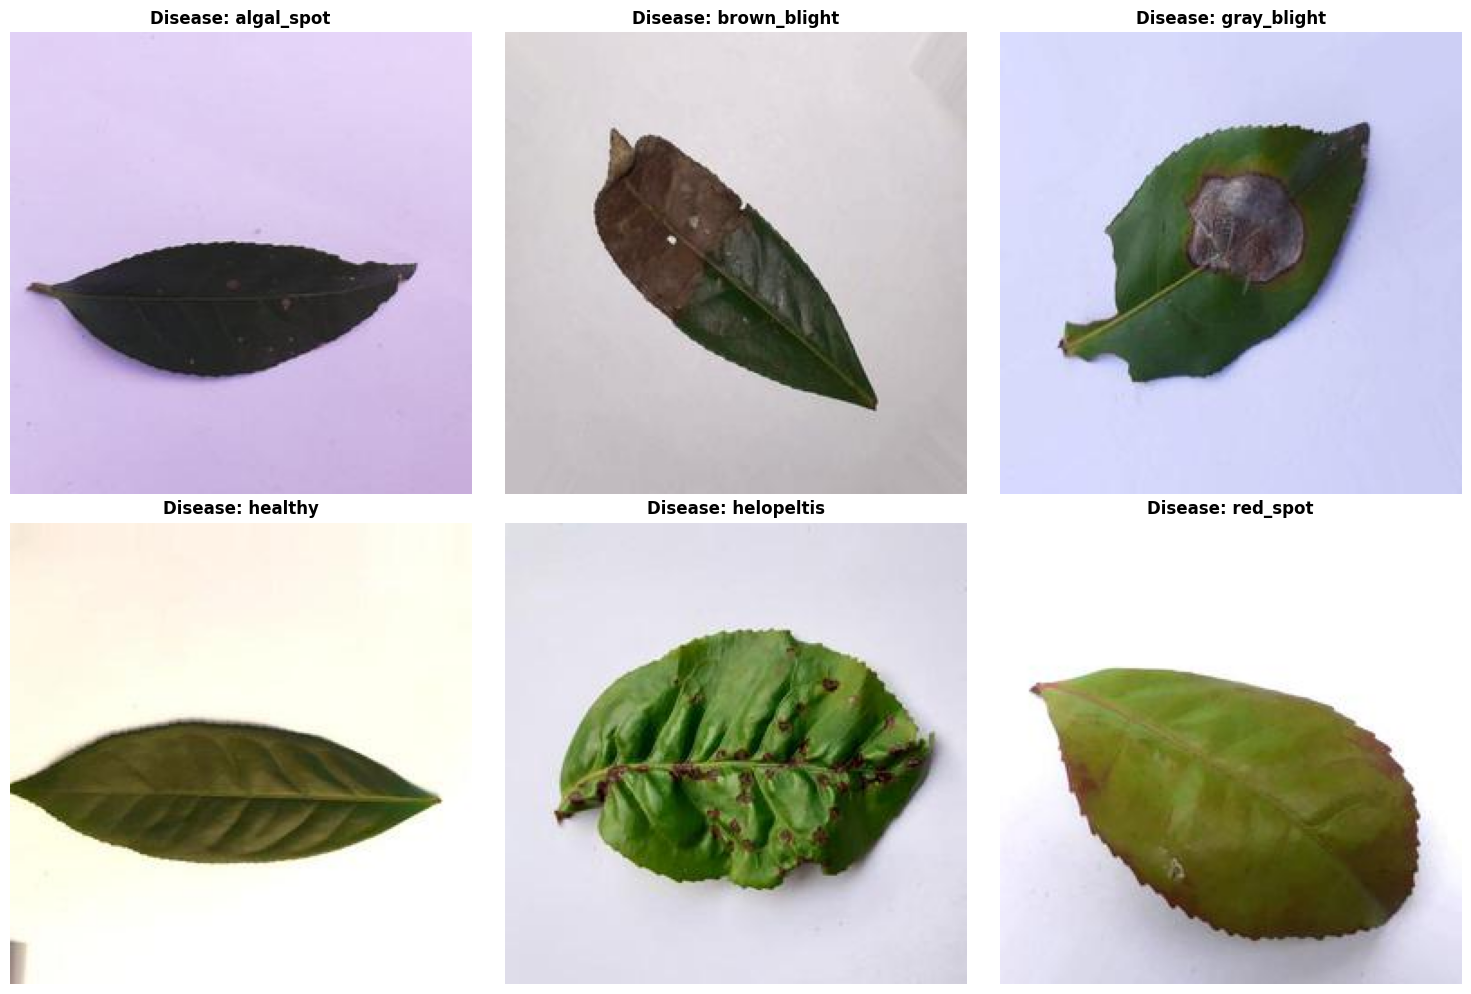

✅ Displayed sample images from all 6 disease classes:
   • algal_spot
   • brown_blight
   • gray_blight
   • healthy
   • helopeltis
   • red_spot


In [30]:
# Path to the directory containing disease class folders
import random

path = "./Tea_Leaf_Disease"
disease_classes = sorted(os.listdir(path))

# Display one image from each disease class
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

for idx, disease in enumerate(disease_classes):
    disease_path = os.path.join(path, disease)
    
    # Get list of images in this disease folder
    images = [f for f in os.listdir(disease_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    if images:
        # Pick a random image from the disease class
        random_image = random.choice(images)
        img_path = os.path.join(disease_path, random_image)
        
        # Load and display the image
        img = mpimg.imread(img_path)
        axs[idx].imshow(img)
        axs[idx].set_title(f"Disease: {disease}", fontsize=12, fontweight='bold')
        axs[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Displayed sample images from all {len(disease_classes)} disease classes:")
for disease in disease_classes:
    print(f"   • {disease}")


In [31]:
# Display sample images statistics
print("\n" + "=" * 70)
print("📊 DATASET STATISTICS")
print("=" * 70)

path = "./Tea_Leaf_Disease"
disease_classes = sorted(os.listdir(path))

total_images = 0
for disease in disease_classes:
    disease_path = os.path.join(path, disease)
    num_images = len([f for f in os.listdir(disease_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    total_images += num_images
    print(f"  {disease:20s}: {num_images:5d} images")

print("=" * 70)
print(f"  {'TOTAL':20s}: {total_images:5d} images")
print("=" * 70)
print(f"\n✅ Ready to train on {len(disease_classes)} disease classes with {total_images} total images")



📊 DATASET STATISTICS
  algal_spot          :  1000 images
  brown_blight        :   867 images
  gray_blight         :  1000 images
  healthy             :  1000 images
  helopeltis          :  1000 images
  red_spot            :  1000 images
  TOTAL               :  5867 images

✅ Ready to train on 6 disease classes with 5867 total images


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;">4 | Training The Model</h1>
</div>

**WORKING**
- The code initializes a `DenseNet121` model with weights pre-trained on the ImageNet dataset.
- The `include_top=False argument` specifies that the model should not include the fully connected layers at the top of the network, which are typically used for ImageNet classification.
- The `input_shape=(256,256,3) argument` specifies the shape of the input images that the model expects, which is `256x256` pixels with 3 channels (RGB).
- The initialized model `conv_base` can be used as a feature extractor to extract features from images, which can then be used as input to a custom classification head.

In [32]:
conv_base = DenseNet121(
    weights='imagenet',
    include_top = False,
    input_shape=(256,256,3),
    pooling='avg'
)

**WHY FALSE ?**
- Setting conv_base.trainable = False freezes the weights of the pre-trained DenseNet121 model.
- This is done to prevent the weights from being updated during the training of the custom classification head.
- Freezing the pre-trained weights helps in utilizing the learned features from the ImageNet dataset without altering them.
- It also reduces the computational cost and training time, as only the weights of the custom classification head will be trained.

In [33]:
conv_base.trainable = False

In [34]:
# # Summary of the pretrained model
# conv_base.summary()

**WORKING**

- It initializes a Sequential model and adds the `pre-trained` DenseNet121` model (conv_base) ` as the base.
- The model flattens the output from the base model and adds two fully connected layers with `ReLU activation`.
- `Batch normalization` is applied after each fully connected layer to improve training stability and speed.

In [35]:
model = Sequential()
model.add(conv_base)
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.35))
model.add(BatchNormalization())
model.add(Dense(120, activation='relu'))
model.add(Dense(6, activation='softmax'))  # ✅ Changed from 10 to 6 classes for tea leaf diseases

**WORKING**

- The compile method is used to configure the model for training.
- The optimizer=Adam(lr=0.0001) argument specifies the Adam optimizer with a learning rate of 0.0001.
- The loss='categorical_crossentropy' argument specifies the loss function used for training, which is categorical crossentropy for multi-class classification.
- The metrics=['accuracy'] argument specifies the metric used to evaluate the model, which is accuracy in this case.

In [36]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

**WORKING**
- The `fit` method is used to train the model on the training data (`train_data`) for a specified number of epochs (100 in this case).
- The `validation_data=val_data` argument specifies the validation data to evaluate the model performance after each epoch.
- The `callbacks=[EarlyStopping(patience=0)]` argument specifies the use of early stopping to prevent overfitting. The training will stop if the validation loss does not improve after 0 epochs.
- The `history` variable stores the training history, including metrics such as loss and accuracy, which can be used for analysis and visualization.

In [37]:
# history = model.fit(train_ds,epochs=10,validation_data=validation_ds)
history = model.fit(train_data, epochs=100, validation_data=val_data, callbacks=[EarlyStopping(patience=5)])  # ✅ Changed from 0 to 5

Epoch 1/100
  1/184 ━━━━━━━━━━━━━━━━━━━━ 1:43:10 34s/step - accuracy: 0.1562 - loss: 2.3530

I0000 00:00:1765053076.166208  519263 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


184/184 ━━━━━━━━━━━━━━━━━━━━ 90s 309ms/step - accuracy: 0.5679 - loss: 1.1815 - val_accuracy: 0.8101 - val_loss: 0.8051
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 90s 309ms/step - accuracy: 0.5679 - loss: 1.1815 - val_accuracy: 0.8101 - val_loss: 0.8051
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 174ms/step - accuracy: 0.8127 - loss: 0.5629 - val_accuracy: 0.8952 - val_loss: 0.3944
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 174ms/step - accuracy: 0.8127 - loss: 0.5629 - val_accuracy: 0.8952 - val_loss: 0.3944
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 175ms/step - accuracy: 0.8628 - loss: 0.4130 - val_accuracy: 0.9286 - val_loss: 0.2483
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 175ms/step - accuracy: 0.8628 - loss: 0.4130 - val_accuracy: 0.9286 - val_loss: 0.2483
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 175ms/step - accuracy: 0.8894 - loss: 0.3207 - val_accuracy: 0.9478 - val_loss: 0.1805
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 175ms/step - accuracy: 0.8894 - loss: 0.320

In [38]:
# Evaluate the model on the validation data
evaluation = model.evaluate(val_data)

# Print the evaluation metrics
print("Validation Loss:", evaluation[0])
print("Validation Accuracy:", evaluation[1])

184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 1.0000 - loss: 2.5958e-05
Validation Loss: 2.5958002879633568e-05
Validation Accuracy: 1.0


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;">5 | THE END </h1>
</div>

In [39]:
# Save the trained Keras model
model.save("trained_model.h5")
print("✅ Keras model saved as trained_model.h5")


✅ Keras model saved as trained_model.h5


In [ ]:
import tensorflow as tf

# Load the saved model
model = tf.keras.models.load_model("trained_model.h5")

# Create TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Optional) Enable optimizations for smaller model size
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save as .tflite
with open("trained_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model converted and saved as trained_model.tflite")


INFO:tensorflow:Assets written to: /tmp/tmps42g9xvs/assets


INFO:tensorflow:Assets written to: /tmp/tmps42g9xvs/assets


Saved artifact at '/tmp/tmps42g9xvs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140611076506832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076265296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076263568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076263376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076270864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076263760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076271056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076271440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076271248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140611076270672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1406110762731

W0000 00:00:1765056364.647948  518943 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1765056364.648024  518943 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1765056364.934522  518943 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


✅ Model converted and saved as trained_model.tflite


: 